# House Price Prediction Using Regression Machine Learning

## Objective
The objective of this project is to perform complete data preprocessing, apply feature scaling, implement multiple regression algorithms, compare their performance, and optimize the best performing model.

## Steps:
1. Data Collection
2. Data Preprocessing
3. Exploratory Data Analysis
4. Feature Engineering
5. Feature Scaling
6. Regression Model Implementation
7. Model Evaluation
8. Hyperparameter Optimization
9. Best Model Selection

In [1]:
# Import Required Libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

## Loading Dataset

The dataset contains house-related features and the target variable represents house price.

Dataset file name:
house_price.csv

In [4]:
# Load Dataset

df = pd.read_csv("housing.csv")

# Display first five rows

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
# Statistical Summary

df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## Data Cleaning

Checking missing values and handling them before model training.

In [7]:
# Missing Values

df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
# Removing Missing Values

df = df.dropna()

print("Missing values removed successfully")

Missing values removed successfully


## Checking Duplicate Records

Duplicate rows can affect the performance of machine learning models, so we check and remove duplicate records.

In [9]:
# Checking duplicate values

df.duplicated().sum()

np.int64(0)

In [10]:
# Removing duplicate values

df = df.drop_duplicates()

print("Duplicate values removed successfully")

Duplicate values removed successfully


## Exploratory Data Analysis

EDA helps us understand the dataset, identify patterns, relationships, and important features.

In [11]:
# Checking dataset columns

df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

## Correlation Matrix

Correlation shows the relationship between different features and the target variable.

Numeric Columns:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')


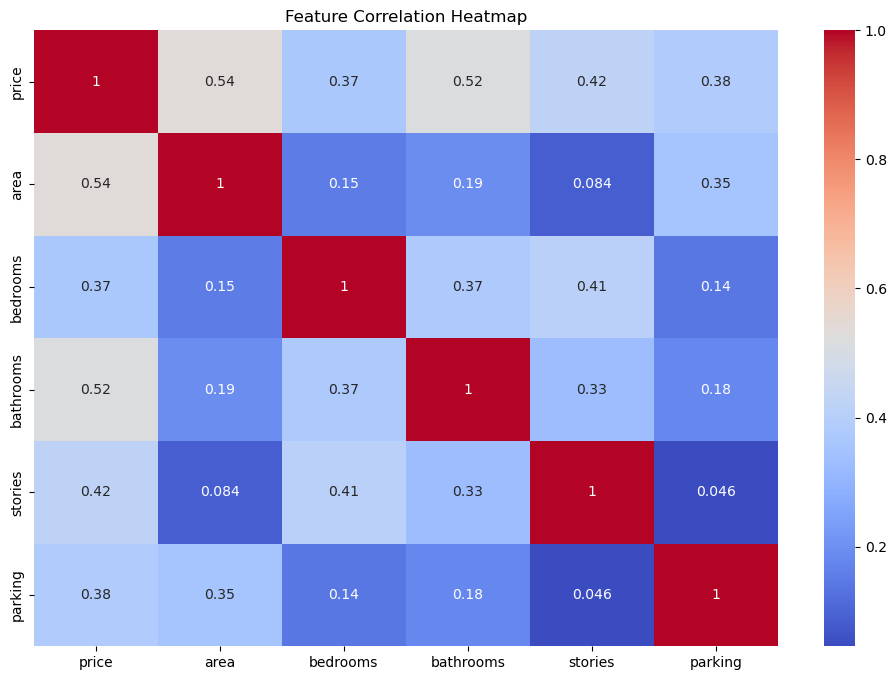

In [15]:
# Selecting only numerical columns

numeric_df = df.select_dtypes(include=['int64', 'float64'])

print("Numeric Columns:")
print(numeric_df.columns)

# Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

## Handling Categorical Features

Machine learning models cannot directly understand text values, so categorical features are converted into numerical values using encoding techniques.

In [16]:
# Checking categorical columns

categorical_columns = df.select_dtypes(include=['object']).columns

categorical_columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [17]:
# Applying One Hot Encoding on categorical columns

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

print("Categorical variables encoded successfully")

Categorical variables encoded successfully


## Separating Features and Target Variable

The input features are separated from the target variable (house price).

In [18]:
# Features

X = df.drop('price', axis=1)

# Target variable

y = df['price']


print("Features:", X.shape)
print("Target:", y.shape)

Features: (545, 13)
Target: (545,)


In [19]:
from sklearn.model_selection import train_test_split

# Splitting dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (436, 13)
X_test: (109, 13)


## Feature Scaling

Feature scaling is applied to normalize the range of input features. StandardScaler is used because it standardizes features by removing the mean and scaling to unit variance.

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


## Linear Regression Model

Linear Regression is a basic regression algorithm used to predict continuous values.

In [22]:
linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

linear_pred = linear_model.predict(X_test_scaled)

In [23]:
tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

tree_pred = tree_model.predict(X_test)

In [24]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)

In [25]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)

In [26]:
gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

gb_pred = gb_model.predict(X_test)

In [28]:
from sklearn.svm import SVR
svr_model = SVR()

svr_model.fit(
    X_train_scaled,
    y_train
)

svr_pred = svr_model.predict(X_test_scaled)

In [29]:
svr_model = SVR()

svr_model.fit(
    X_train_scaled,
    y_train
)

svr_pred = svr_model.predict(
    X_test_scaled
)

print("SVR Model Trained Successfully")

SVR Model Trained Successfully


## Model Evaluation

All regression models are evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return [
        model_name,
        mae,
        rmse,
        r2
    ]

In [31]:
results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_pred
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        tree_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gb_pred
    )
)

results.append(
    evaluate_model(
        "SVR",
        y_test,
        svr_pred
    )
)


comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)


comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Decision Tree,1.195266e+06,1.625670e+06,0.477146
2,Random Forest,1.021546e+06,1.400566e+06,0.611919
3,Gradient Boosting,9.597490e+05,1.299386e+06,0.665965
4,SVR,1.763890e+06,2.359649e+06,-0.101566


## Best Model Selection

Based on the comparison results, Gradient Boosting Regression achieved the highest R² score. Therefore, it is selected as the best model for hyperparameter optimization.

In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor


# Parameters for tuning

parameters = {
    'n_estimators':[100,200,300],
    'learning_rate':[0.01,0.05,0.1],
    'max_depth':[3,5,7],
    'min_samples_split':[2,5,10]
}


grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    parameters,
    cv=5,
    scoring='r2',
    n_jobs=-1
)


grid_search.fit(
    X_train,
    y_train
)


print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 100}


In [33]:
best_gb_model = grid_search.best_estimator_

final_prediction = best_gb_model.predict(
    X_test
)


final_r2 = r2_score(
    y_test,
    final_prediction
)


print("Optimized Gradient Boosting R2 Score:", final_r2)

Optimized Gradient Boosting R2 Score: 0.6465520663077642


## Final Prediction

The optimized model is used to predict house prices on unseen test data.

In [34]:
# Display Actual vs Predicted Values

result = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": final_prediction
})

result.head(10)

,Actual Price,Predicted Price
316,4060000,4.650670e+06
77,6650000,7.149875e+06
360,3710000,3.735772e+06
90,6440000,4.396161e+06
493,2800000,3.708223e+06
209,4900000,4.154602e+06
176,5250000,5.652802e+06
249,4543000,5.742486e+06
516,2450000,3.016555e+06
426,3353000,3.139047e+06


# Conclusion

In this project, a complete regression machine learning pipeline was implemented.

The dataset was cleaned and preprocessed by handling missing values, removing duplicates, and encoding categorical variables.

Different regression algorithms were trained including:

- Linear Regression
- Decision Tree Regression
- Random Forest Regression
- Gradient Boosting Regression
- Support Vector Regression

The performance of all models was compared using MAE, RMSE, and R² Score.

Gradient Boosting Regression achieved the best performance among all models. Hyperparameter tuning was applied using GridSearchCV to further improve the model performance.

The final optimized model can effectively predict house prices based on input features.

# House Price Prediction Using Regression Machine Learning

## Project Overview

This project focuses on predicting house prices using different regression machine learning algorithms.

## Dataset

The dataset contains house features and the target variable represents house prices.

## Machine Learning Models Used

- Linear Regression
- Decision Tree Regression
- Random Forest Regression
- Gradient Boosting Regression
- Support Vector Regression

## Data Preprocessing

The following preprocessing techniques were applied:

- Missing value handling
- Duplicate removal
- Categorical encoding
- Feature scaling

## Evaluation Metrics

Models were evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

## Best Model

Gradient Boosting Regression achieved the highest performance.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

## How to Run

1. Install required libraries
2. Open Jupyter Notebook
3. Run all cells sequentially